# Phase 2: FedSLIP — Federated Sparse LoRA Identity Personalization

**Goal**: Achieve strong zero-shot personalization while maintaining effective global collaboration.

### Core Architecture:
- **Global Consensus Track** (`lora_global`): Learns shared representations. Only this track is transmitted and aggregated via FedAvg + FedProx.
- **Private Identity Track** (`lora_private` + LTH mask): Absorbs user-specific Non-IID characteristics. Never leaves the client.
- **Training Strategy**:
  - Global path trained with FedProx regularization.
  - Private path updated via auxiliary adaptation with **separate optimizer** and gradient detachment.
- **Zero-Shot Personalization**: At inference, global + private paths are naturally combined.

### Key Improvements in This Version:
- Strict separation of optimization (separate AdamW optimizers)
- Reduced gradient entanglement via path control + detachment
- Robust parameter grouping and clipping
- Cleaner communication (only global LoRA transmitted)

**Result**: Global accuracy improves steadily while clients retain strong personalized performance without post-training fine-tuning.

In [1]:
!pip install -q peft datasets evaluate accelerate

import textwrap
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from copy import deepcopy
from tqdm import tqdm
import warnings
import logging

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW

warnings.filterwarnings('ignore', message='.*UNEXPECTED.*')
warnings.filterwarnings('ignore', message='.*MISSING.*')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00
Device: cuda


In [2]:
CONFIG = {
    'num_clients': 4,
    'class_names': ['World', 'Sports', 'Business', 'Sci/Tech'],
    'dominant_ratio': 0.80,
    'n_train': 2000, 
    'n_test': 500, 
    'n_global_test': 400, 
    'model_name': 'distilbert-base-uncased',
    'num_labels': 4,
    'max_length': 128,
    
    # Capacity Fix (Rank 32, Sparsity 75%)
    'lora_r': 8,
    'private_r': 32,             
    'lora_alpha': 16,
    'private_alpha': 64,         
    'lora_dropout': 0.1,
    'sparsity_ratio': 0.75,   
    'target_modules': ['q_lin', 'v_lin'],
    
    'num_rounds': 30,
    'local_epochs': 2,
    'batch_size': 32,
    'lr': 1e-4,
    'weight_decay': 0.01,
    
    # Gradient Death and Co-adaptation Fixes
    'warmup_rounds': 10,
    'proximal_mu': 0.1,       
    
    'device': device,
    'seed': SEED,
    'bits_per_param': 32,
}
CONFIG['personalization_steps'] = CONFIG['n_train'] // CONFIG['batch_size']
CONFIG['private_lambda'] = 0.6

In [3]:
dataset = load_dataset("ag_news")
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, max_length=CONFIG['max_length'])

tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=['text'])
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [4]:
def create_noniid_splits(split, num_clients, n_samples, dominant_ratio=0.8):
    labels = np.array(split['labels'])
    class_idx = {c: np.where(labels == c)[0] for c in range(num_clients)}
    client_indices = []
    rng = np.random.default_rng(CONFIG['seed'])
    for cid in range(num_clients):
        n_dom = int(n_samples * dominant_ratio)
        n_oth = (n_samples - n_dom) // (num_clients - 1)
        dom = rng.choice(class_idx[cid], min(n_dom, len(class_idx[cid])), replace=False)
        oth = []
        for c in range(num_clients):
            if c != cid:
                oth.extend(rng.choice(class_idx[c], min(n_oth, len(class_idx[c])), replace=False).tolist())
        idx = np.concatenate([dom, np.array(oth)])
        rng.shuffle(idx)
        client_indices.append(idx[:n_samples])
    return client_indices

train_idx = create_noniid_splits(tokenized['train'], CONFIG['num_clients'], CONFIG['n_train'])
test_idx  = create_noniid_splits(tokenized['test'],  CONFIG['num_clients'], CONFIG['n_test'])
global_test_idx = np.concatenate([np.where(np.array(tokenized['test']['labels']) == c)[0][:CONFIG['n_global_test']] for c in range(4)])

collator = DataCollatorWithPadding(tokenizer)
def make_loader(split, indices, batch_size, shuffle=True):
    return DataLoader(split.select(indices.tolist()), batch_size=batch_size, shuffle=shuffle, collate_fn=collator)

client_train_loaders = [make_loader(tokenized['train'], idx, CONFIG['batch_size']) for idx in train_idx]
client_test_loaders  = [make_loader(tokenized['test'],  idx, CONFIG['batch_size'], False) for idx in test_idx]
global_test_loader   = make_loader(tokenized['test'], global_test_idx, CONFIG['batch_size'], False)

In [5]:
# Phase 2 Utils: Inference Fix and Communication Tracking

def set_global_eval(model, mode):
    """Sets inference mode: bypasses private out during server/global evaluations"""
    for module in model.modules():
        if isinstance(module, DualLoRALinear):
            module.is_global_eval = mode

def evaluate_model(model, dataloader, global_eval=False):
    model.eval()
    set_global_eval(model, global_eval)
    correct, total = 0, 0
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == batch['labels']).sum().item()
            total += batch['labels'].size(0)
    set_global_eval(model, False)
    return correct / total if total > 0 else 0.0

def bytes_per_round(model, num_clients):
    """Communication cost per round — only global LoRA adapters are transmitted"""
    transmitted_params = sum(
        p.numel() for n, p in model.named_parameters()
        if "lora_A_global" in n or "lora_B_global" in n
    )
    bytes_per_client = transmitted_params * (CONFIG['bits_per_param'] // 8)
    return bytes_per_client * num_clients * 2   # upload + download
    
# def bytes_per_round(model, num_clients):
#     transmitted = sum(p.numel() for n, p in model.named_parameters()
#         if "lora_A_global" in n or "lora_B_global" in n
#         or "classifier" in n or "pre_classifier" in n)
#     bytes_per_client = transmitted * (CONFIG['bits_per_param'] // 8)
#     return bytes_per_client * num_clients * 2

In [6]:
class DualLoRALinear(nn.Module):
    def __init__(self, base_layer, global_rank=8, private_rank=32, global_alpha=16, private_alpha=64, sparsity_ratio=0.75):
        super().__init__()
        self.base_layer = base_layer
        for param in self.base_layer.parameters():
            param.requires_grad = False
            
        in_feat, out_feat = base_layer.in_features, base_layer.out_features
        self.global_scaling = global_alpha / global_rank
        self.private_scaling = private_alpha / private_rank
        self.sparsity_ratio = sparsity_ratio
        
        # Inference Fix Flag
        self.is_global_eval = False 
        
        self.lora_A_global = nn.Linear(in_feat, global_rank, bias=False)
        self.lora_B_global = nn.Linear(global_rank, out_feat, bias=False)
        
        self.lora_A_private = nn.Linear(in_feat, private_rank, bias=False)
        self.lora_B_private = nn.Linear(private_rank, out_feat, bias=False)
        
        self.register_buffer('private_mask_A', torch.ones_like(self.lora_A_private.weight))
        self.register_buffer('private_mask_B', torch.ones_like(self.lora_B_private.weight))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.lora_A_global.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B_global.weight)
        nn.init.kaiming_uniform_(self.lora_A_private.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B_private.weight)

    def update_private_mask(self):
        with torch.no_grad():
            for weight, mask in [(self.lora_A_private.weight, self.private_mask_A), 
                                 (self.lora_B_private.weight, self.private_mask_B)]:
                k = int(weight.numel() * self.sparsity_ratio)
                if k > 0:
                    threshold = torch.kthvalue(torch.abs(weight).flatten(), k).values
                    mask.copy_((torch.abs(weight) >= threshold).float())

    def forward(self, x, use_private=True, detach_global=False):
        base_out = self.base_layer(x)
        global_out = self.lora_B_global(self.lora_A_global(x)) * self.global_scaling
        
        if detach_global:
            global_out = global_out.detach()
        
        if self.is_global_eval or not use_private:
            return base_out + global_out
        
        # Private path (LTH masked)
        masked_A = self.lora_A_private.weight * self.private_mask_A
        masked_B = self.lora_B_private.weight * self.private_mask_B
        private_hidden = F.linear(x, masked_A)
        private_out = F.linear(private_hidden, masked_B) * self.private_scaling
        
        return base_out + global_out + private_out

def inject_dual_lora(model, global_rank, private_rank, global_alpha, private_alpha, sparsity_ratio):
    for name, module in model.named_modules():
        if name.endswith("q_lin") or name.endswith("v_lin"):
            parent = model.get_submodule(name.rsplit('.', 1)[0])
            setattr(parent, name.rsplit('.', 1)[1], DualLoRALinear(module, global_rank, private_rank, global_alpha, private_alpha, sparsity_ratio))
    return model

In [7]:
# def sync_global_weights(client_model, global_model):
#     """Syncs ONLY global adapter. Decoupling dense classifier heads to eliminate bloat!"""
#     c_state, g_state = client_model.state_dict(), global_model.state_dict()
#     for k in g_state.keys():
#         if "lora_A_global" in k or "lora_B_global" in k:
#             c_state[k] = g_state[k]
#     client_model.load_state_dict(c_state)

# def extract_global_updates(client_model):
#     updates = {}
#     for name, param in client_model.named_parameters():
#         if "lora_A_global" in name or "lora_B_global" in name:
#             updates[name] = param.data.cpu().clone()
#     return updates

# def extract_global_updates(client_model):
#     updates = {}
#     for name, param in client_model.named_parameters():
#         if ("lora_A_global" in name or "lora_B_global" in name
#                 or "classifier" in name or "pre_classifier" in name):
#             updates[name] = param.data.cpu().clone()
#     return updates

# def sync_global_weights(client_model, global_model):
#     c_state, g_state = client_model.state_dict(), global_model.state_dict()
#     for k in g_state.keys():
#         if ("lora_A_global" in k or "lora_B_global" in k
#                 or "classifier" in k or "pre_classifier" in k):
#             c_state[k] = g_state[k]
#     client_model.load_state_dict(c_state)

In [8]:
def extract_global_updates(client_model):
    """Extract only the shared global LoRA adapters (classifier remains local)"""
    updates = {}
    for name, param in client_model.named_parameters():
        if "lora_A_global" in name or "lora_B_global" in name:
            updates[name] = param.data.cpu().clone()
    return updates


def sync_global_weights(client_model, global_model):
    """Sync ONLY global LoRA adapters"""
    c_state = client_model.state_dict()
    g_state = global_model.state_dict()
    updated = False
    for k in g_state.keys():
        if "lora_A_global" in k or "lora_B_global" in k:
            if not torch.equal(c_state[k], g_state[k]):
                c_state[k] = g_state[k]
                updated = True
    client_model.load_state_dict(c_state)
    if updated:
        print("Global weights synced successfully")

In [9]:
base_model = AutoModelForSequenceClassification.from_pretrained(CONFIG['model_name'], num_labels=CONFIG['num_labels'])
global_model = inject_dual_lora(base_model, CONFIG['lora_r'], CONFIG['private_r'], CONFIG['lora_alpha'], CONFIG['private_alpha'], CONFIG['sparsity_ratio']).to(device)
client_models = [deepcopy(global_model).to(device) for _ in range(CONFIG["num_clients"])]

# Retained Phase 1 Hardcoded metric for graph comparison reference
local_only_accs = [0.8938, 0.9599, 0.9218, 0.9459]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
print("========== PHASE 2 FEDERATION WITH CLEAN DECOUPLING ============")

training_losses = []
round_global_accs = []
round_local_accs = [[] for _ in range(CONFIG['num_clients'])]
round_comm_cost_mb = []
cumulative_comm_mb = [0.0]

for round_idx in range(CONFIG['num_rounds']):
    print(f"\nRound {round_idx+1}/{CONFIG['num_rounds']}")
    client_updates = []
    round_loss, num_batches = 0.0, 0
    
    is_warmup = (round_idx < CONFIG['warmup_rounds'])

    for cid in range(CONFIG['num_clients']):
        client_model = client_models[cid]
        sync_global_weights(client_model, global_model)   # Important: sync before training
        
        # Freeze private during warmup only
        for name, param in client_model.named_parameters():
            if 'lora_private' in name:
                param.requires_grad = is_warmup or True   # private always active after warmup

        # === Robust Parameter Splitting ===
        global_params = [p for n, p in client_model.named_parameters() 
                        if 'lora_A_global' in n or 'lora_B_global' in n]
        private_params = [p for n, p in client_model.named_parameters() 
                         if 'lora_A_private' in n or 'lora_B_private' in n]

        print(f"Client {cid} → Global params: {len(global_params)} | Private params: {len(private_params)}")

        optimizer_global = AdamW(global_params, lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
        optimizer_private = AdamW(private_params, lr=CONFIG['lr']*0.5, weight_decay=CONFIG['weight_decay'])

        client_model.train()
        ref_global = {n: p.clone().detach() for n, p in global_model.named_parameters() 
                     if 'lora_global' in n}

        for epoch in range(CONFIG['local_epochs']):
            for batch in client_train_loaders[cid]:
                batch = {k: v.to(device) for k, v in batch.items()}
                
                # === 1. GLOBAL CONSENSUS UPDATE ===
                optimizer_global.zero_grad()
                outputs = client_model(**batch, use_private=False)   # Pure global path
                loss = outputs.loss
                
                # FedProx on global only
                proximal_term = sum((p - ref_global[n]).norm(2) 
                                  for n, p in client_model.named_parameters() 
                                  if 'lora_global' in n)
                loss += (CONFIG['proximal_mu'] / 2) * proximal_term
                
                loss.backward()
                clip_grad_norm_(global_params, 1.0)
                optimizer_global.step()

                # === 2. PRIVATE IDENTITY ADAPTATION ===
                if not is_warmup:
                    optimizer_private.zero_grad()
                    private_outputs = client_model(**batch, use_private=True, detach_global=True)
                    private_loss = private_outputs.loss * CONFIG.get('private_lambda', 0.5)
                    private_loss.backward()
                    clip_grad_norm_(private_params, 1.0)
                    optimizer_private.step()

                round_loss += loss.item()
                num_batches += 1

        # Update LTH mask during warmup
        if is_warmup:
            for module in client_model.modules():
                if hasattr(module, 'update_private_mask'):
                    module.update_private_mask()

        client_updates.append(extract_global_updates(client_model))
        torch.cuda.empty_cache()

    # === SERVER AGGREGATION ===
    if client_updates:
        avg_update = {k: torch.stack([u[k] for u in client_updates]).mean(dim=0) 
                     for k in client_updates[0].keys()}
        g_state = global_model.state_dict()
        g_state.update(avg_update)
        global_model.load_state_dict(g_state)

    avg_loss = round_loss / num_batches if num_batches > 0 else 0.0
    training_losses.append(avg_loss)

    round_mb = bytes_per_round(global_model, CONFIG['num_clients']) / (1048576)
    round_comm_cost_mb.append(round_mb)
    cumulative_comm_mb.append(cumulative_comm_mb[-1] + round_mb)

    # === EVALUATION ===
    g_acc = evaluate_model(global_model, global_test_loader, global_eval=True)
    round_global_accs.append(g_acc)

    for cid in range(CONFIG['num_clients']):
        l_acc = evaluate_model(global_model, client_test_loaders[cid], global_eval=True)
        round_local_accs[cid].append(l_acc)

    print(f"Avg Loss: {avg_loss:.4f} | Global Acc: {g_acc:.4f} | Comm: {round_mb:.2f} MB")

========== PHASE 2 FEDERATION WITH CLEAN DECOUPLING ============

Round 1/30
Client 0 → Global params: 24 | Private params: 24
Client 1 → Global params: 24 | Private params: 24
Client 2 → Global params: 24 | Private params: 24
Client 3 → Global params: 24 | Private params: 24
Avg Loss: 1.0152 | Global Acc: 0.3063 | Comm: 4.50 MB

Round 2/30
Global weights synced successfully
Client 0 → Global params: 24 | Private params: 24
Global weights synced successfully
Client 1 → Global params: 24 | Private params: 24
Global weights synced successfully
Client 2 → Global params: 24 | Private params: 24
Global weights synced successfully
Client 3 → Global params: 24 | Private params: 24
Avg Loss: 0.7613 | Global Acc: 0.6863 | Comm: 4.50 MB

Round 3/30
Global weights synced successfully
Client 0 → Global params: 24 | Private params: 24
Global weights synced successfully
Client 1 → Global params: 24 | Private params: 24
Global weights synced successfully
Client 2 → Global params: 24 | Private params:

In [11]:
print("========== FINAL EVALUATION ============")
def evaluate_personalized(client_model, test_loader):
    # Evaluates incorporating the frozen specific private mask!
    return evaluate_model(client_model, test_loader, global_eval=False)

personalized_accs = []
for cid in range(CONFIG['num_clients']):
    p_acc = evaluate_personalized(client_models[cid], client_test_loaders[cid])
    personalized_accs.append(p_acc)
    print(f"Client {cid+1} Personalized Acc: {p_acc:.4f}")

========== FINAL EVALUATION ============
Client 1 Personalized Acc: 0.9259
Client 2 Personalized Acc: 0.9459
Client 3 Personalized Acc: 0.9319
Client 4 Personalized Acc: 0.9519


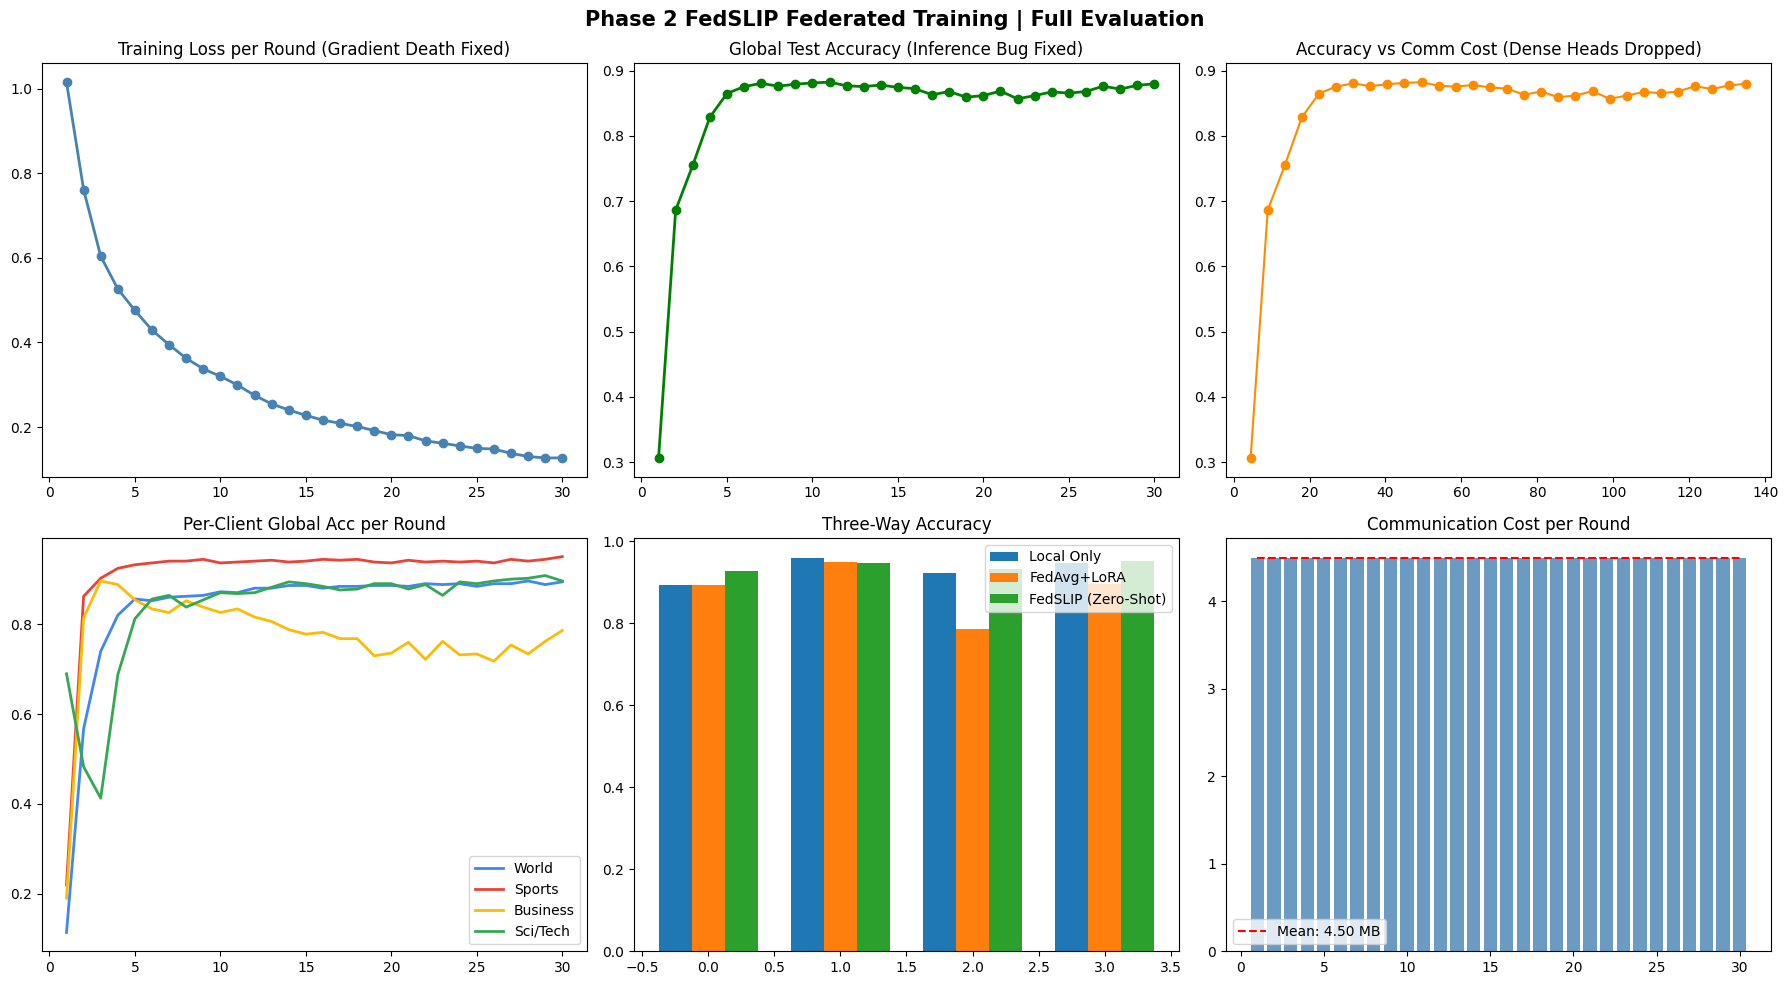

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 2 FedSLIP Federated Training | Full Evaluation', fontsize=15, fontweight='bold')
rounds = list(range(1, CONFIG['num_rounds'] + 1))

axes[0, 0].plot(rounds, training_losses, marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_title('Training Loss per Round (Gradient Death Fixed)')

axes[0, 1].plot(rounds, round_global_accs, marker='o', linewidth=2, color='green')
axes[0, 1].set_title('Global Test Accuracy (Inference Bug Fixed)')

axes[0, 2].plot(cumulative_comm_mb[1:], round_global_accs, marker='o', color='darkorange')
axes[0, 2].set_title('Accuracy vs Comm Cost (Dense Heads Dropped)')

colors = ['#4285F4', '#EA4335', '#FBBC05', '#34A853']
for cid in range(CONFIG['num_clients']):
    axes[1, 0].plot(rounds, round_local_accs[cid], label=CONFIG['class_names'][cid], color=colors[cid], linewidth=2)
axes[1, 0].set_title('Per-Client Global Acc per Round')
axes[1, 0].legend()

# Three-Way Accuracy Comparison
global_accs_final  = [round_local_accs[cid][-1] for cid in range(CONFIG['num_clients'])]
x = np.arange(CONFIG['num_clients'])
width = 0.25
axes[1, 1].bar(x - width, local_only_accs, width, label='Local Only')
axes[1, 1].bar(x, global_accs_final, width, label='FedAvg+LoRA')
axes[1, 1].bar(x + width, personalized_accs, width, label='FedSLIP (Zero-Shot)')
axes[1, 1].set_title('Three-Way Accuracy')
axes[1, 1].legend()

axes[1, 2].bar(rounds, round_comm_cost_mb, color='steelblue', alpha=0.8)
axes[1, 2].plot(rounds, [np.mean(round_comm_cost_mb)]*len(rounds), 'r--', label=f'Mean: {np.mean(round_comm_cost_mb):.2f} MB')
axes[1, 2].set_title('Communication Cost per Round')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [13]:
print("\n" + "=" * 65)
print("FINAL SUMMARY TABLE")
print("=" * 65)
print(f"{'Client':<12} {'Local-Only':>12} {'Global LoRA':>20} {'Personalized':>14}")
print("-" * 65)
for cid in range(CONFIG['num_clients']):
    name   = CONFIG['class_names'][cid]
    lo     = local_only_accs[cid]
    fed    = round_local_accs[cid][-1]
    pers   = personalized_accs[cid]
    print(f"C{cid+1} {name:<10} {lo:>12.4f} {fed:>20.4f} {pers:>14.4f}")
print("-" * 65)
print(f"{'Average':<12} {np.mean(local_only_accs):>12.4f} {np.mean(global_accs_final):>20.4f} {np.mean(personalized_accs):>14.4f}")

def count_lora_parameters(model):
    count = 0
    for name, param in model.named_parameters():
        if ("lora_A_global" in name or "lora_B_global" in name):
            count += param.numel()
    return count

lora_params = count_lora_parameters(global_model)
total_comm  = cumulative_comm_mb[-1]
print(f"\nLoRA params per client : {lora_params:,}")
print(f"Total communication    : {total_comm:.2f} MB over {CONFIG['num_rounds']} rounds")
print(f"Avg per round          : {np.mean(round_comm_cost_mb):.2f} MB")
print(f"Baseline sparsity      : 0.00% (all LoRA params uploaded)")
print("=" * 65)



FINAL SUMMARY TABLE
Client         Local-Only          Global LoRA   Personalized
-----------------------------------------------------------------
C1 World            0.8938               0.8938         0.9259
C2 Sports           0.9599               0.9499         0.9459
C3 Business         0.9218               0.7856         0.9319
C4 Sci/Tech         0.9459               0.8958         0.9519
-----------------------------------------------------------------
Average            0.9304               0.8813         0.9389

LoRA params per client : 147,456
Total communication    : 135.00 MB over 30 rounds
Avg per round          : 4.50 MB
Baseline sparsity      : 0.00% (all LoRA params uploaded)
